# Interfaz programática del metamodelo PINN — Familia B
**Predicción modal y respuesta sísmica NCh433 + DS61**

Esta interfaz carga el modelo PINN entrenado (Fase 2, seed 2718) y permite predecir, para un edificio de la Familia B definido por el usuario:

- **Respuesta modal**: períodos T₁…T₁₈ y formas modales Φ.
- **Respuesta sísmica por piso**: desplazamientos Uₓ, U_y y derivas δₓ, δ_y.
- **Respuesta global**: cortes basales V_b,x y V_b,y.
- **Verificación normativa** (NCh433): deriva ≤ 0.002, masa modal ≥ 90%, con identificación del piso/dirección donde falla, si falla.

> Advertencia importante: el metamodelo opera de forma confiable únicamente dentro del dominio de entrenamiento. Esta interfaz **valida el dominio** y advierte cuando los parámetros del edificio caen fuera, sobre todo en número de pisos.

In [9]:
# ============================================================
# CELDA 0 — PANEL DE CONFIGURACIÓN
# ── Único lugar que se edita: rutas al modelo y a los scalers ──
# ============================================================
from pathlib import Path

MODEL_PATH   = Path('model_fase2_seed2718.pt')
SCALERS_PATH = Path('scalers_trial16.pkl')

DRIFT_LIMIT_NCh433 = 0.002
MASS_PARTIC_MIN    = 0.90
G                  = 9.81

MODEL_TAG = 'PINNModal_v4b — Fase 2 seed 2718'

print('=' * 60)
print('INTERFAZ PINN — FAMILIA B')
print('=' * 60)
print(f'  Modelo  : {MODEL_PATH}')
print(f'  Scalers : {SCALERS_PATH}')
print(f'  Versión : {MODEL_TAG}')
print('=' * 60)

INTERFAZ PINN — FAMILIA B
  Modelo  : model_fase2_seed2718.pt
  Scalers : scalers_trial16.pkl
  Versión : PINNModal_v4b — Fase 2 seed 2718


In [10]:
# ============================================================
# CELDA 1 — Imports + arquitectura PINNModal_v4b
# ============================================================
import numpy as np, pickle, math
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class ResBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim), nn.LayerNorm(dim), nn.SiLU(),
            nn.Linear(dim, dim), nn.LayerNorm(dim))
        self.act = nn.SiLU()
    def forward(self, x): return self.act(x + self.net(x))

class PINNModal_v4(nn.Module):
    def __init__(self, n_inputs=21, n_modos=18, n_max_pisos=18,
                 hidden=256, hidden_T1=128):
        super().__init__()
        self.n_modos = n_modos
        self.n_max_pisos = n_max_pisos
        self.encoder_T1 = nn.Sequential(
            nn.Linear(n_inputs, hidden_T1), nn.LayerNorm(hidden_T1), nn.SiLU(),
            ResBlock(hidden_T1), ResBlock(hidden_T1))
        self.head_T1 = nn.Sequential(nn.Linear(hidden_T1, 32), nn.SiLU(), nn.Linear(32, 1))
        self.encoder = nn.Sequential(
            nn.Linear(n_inputs, hidden), nn.LayerNorm(hidden), nn.SiLU(),
            ResBlock(hidden), ResBlock(hidden), ResBlock(hidden), ResBlock(hidden))
        self.head_T_rest = nn.Sequential(nn.Linear(hidden, 128), nn.SiLU(),
                                         nn.Linear(128, n_modos - 1))
        self.head_Phi    = nn.Sequential(nn.Linear(hidden, 512), nn.SiLU(),
                                         nn.Linear(512, n_modos * n_max_pisos * 3))
        self.head_resp   = nn.Sequential(nn.Linear(hidden, 256), nn.SiLU(),
                                         nn.Linear(256, n_max_pisos * 4))
        self.head_Vb     = nn.Sequential(nn.Linear(hidden, 64), nn.SiLU(), nn.Linear(64, 2))

    def forward(self, X, mask):
        B = X.shape[0]
        h_T1 = self.encoder_T1(X)
        T1_out = self.head_T1(h_T1)
        h = self.encoder(X)
        T_deltas = F.softplus(self.head_T_rest(h))
        T_parts = [T1_out]
        for r in range(self.n_modos - 1):
            T_parts.append(T_parts[-1] - T_deltas[:, r:r+1])
        logT_pred = torch.cat(T_parts, dim=1)
        Phi_raw  = self.head_Phi(h).view(B, self.n_modos, self.n_max_pisos, 3)
        mask_4d  = mask.unsqueeze(1).unsqueeze(-1)
        Phi_raw  = Phi_raw * mask_4d
        norma    = Phi_raw.norm(dim=2, keepdim=True).clamp(min=1e-8)
        Phi_norm = Phi_raw / norma
        Phi_all  = Phi_norm.permute(0, 2, 1, 3)
        Phi_x_p, Phi_y_p, Phi_t_p = Phi_all[..., 0], Phi_all[..., 1], Phi_all[..., 2]
        resp = self.head_resp(h).view(B, self.n_max_pisos, 4)
        Ux_p = resp[..., 0] * mask
        Uy_p = resp[..., 1] * mask
        ratio_p = F.softplus(resp[..., 2]) * mask
        dy_p = resp[..., 3] * mask
        dx_p = ratio_p * dy_p
        Vb_p = self.head_Vb(h)
        return logT_pred, Phi_x_p, Phi_y_p, Phi_t_p, Ux_p, Uy_p, dx_p, dy_p, Vb_p, ratio_p

print('Arquitectura definida: PINNModal_v4b')

Arquitectura definida: PINNModal_v4b


In [13]:
# ============================================================
# CELDA 2 — Carga del modelo y los scalers
# ============================================================
from pathlib import Path
import pickle
import torch

MODEL_PATH = Path(
    r"C:\Users\rodri\Documents\PINN\b2_proyecto\models\trials_31\V8\DEFINITIVO\model_fase2_seed2718.pt"
)

SCALERS_PATH = Path(
    r"C:\Users\rodri\Documents\PINN\b2_proyecto\models\trials_31\V8\DEFINITIVO\scalers_trial16.pkl"
)

assert MODEL_PATH.exists(),   f'Falta el modelo: {MODEL_PATH}'
assert SCALERS_PATH.exists(), f'Faltan los scalers: {SCALERS_PATH}'

model = PINNModal_v4().to(device)

sd = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(sd, strict=True)

model.eval()

with open(SCALERS_PATH, 'rb') as f:
    SC = pickle.load(f)

COLS_BASE = SC['COLS_BASE']

N_PARAMS = sum(p.numel() for p in model.parameters())

print(f'Modelo cargado: {N_PARAMS:,} parámetros en {device}')
print(f'Scalers cargados: {len(COLS_BASE)} features')
print(f'Features: {COLS_BASE}')

Modelo cargado: 1,377,064 parámetros en cuda
Scalers cargados: 21 features
Features: ['N_pisos', 'n_unid_lado', 'activar_B2', 'L_mod_m', 'prof_depto_m', 'ancho_corredor_m', 'L_nucleo_m', 'B_nucleo_m', 'h_story_m', 'fc_MPa', 'gk_kN_m2', 't_muro_nucleo_m', 't_muro_borde_m', 't_muro_mid_m', 'suelo_A', 'suelo_B', 'suelo_C', 'suelo_D', 'zona_1', 'zona_2', 'zona_3']


In [14]:
# ============================================================
# CELDA 3 — Dominio de entrenamiento y validación de parámetros
# ============================================================
DOMAIN = {
    'N_pisos'         : {'min': 6,    'max': 18,   'tipo': 'int'},
    'n_unid_lado'     : {'min': 2,    'max': 6,    'tipo': 'int'},
    'activar_B2'      : {'set': [0, 1]},
    'L_mod_m'         : {'min': 3.20, 'max': 3.80, 'tipo': 'float'},
    'prof_depto_m'    : {'min': 7.00, 'max': 7.90, 'tipo': 'float'},
    'ancho_corredor_m': {'min': 1.50, 'max': 1.90, 'tipo': 'float'},
    'L_nucleo_m'      : {'min': 5.40, 'max': 6.60, 'tipo': 'float'},
    'B_nucleo_m'      : {'min': 4.00, 'max': 5.00, 'tipo': 'float'},
    'h_story_m'       : {'set': [2.60, 2.70, 2.80, 2.90]},
    'fc_MPa'          : {'set': [25, 30, 35, 40]},
    'gk_kN_m2'        : {'set': [6.0, 6.5, 7.0, 7.5]},
    't_muro_nucleo_m' : {'set': [0.18, 0.20, 0.22, 0.25, 0.28, 0.30]},
    't_muro_borde_m'  : {'set': [0.18, 0.20, 0.22, 0.25, 0.28, 0.30]},
    't_muro_mid_m'    : {'set': [0.15, 0.18, 0.20, 0.22, 0.25]},
    'suelo'           : {'set': ['A', 'B', 'C', 'D']},
    'zona'            : {'set': [1, 2, 3]},
}

def validar_dominio(params):
    """Devuelve (lista de avisos, bandera de fuera de dominio grave)."""
    avisos = []
    grave  = False
    for k, dom in DOMAIN.items():
        if k not in params: continue
        v = params[k]
        if 'set' in dom and v not in dom['set']:
            avisos.append(f"  ⚠️  '{k}={v}' fuera del catálogo {dom['set']}")
            grave = True
        elif 'min' in dom:
            if v < dom['min'] or v > dom['max']:
                avisos.append(f"  ⚠️  '{k}={v}' fuera del rango [{dom['min']}, {dom['max']}]")
                if k == 'N_pisos': grave = True
    return avisos, grave

In [15]:
# ============================================================
# CELDA 4 — Constructores de edificio: MODO EXPERTO y MODO SIMPLE
# ============================================================
def edificio_experto(N_pisos, n_unid_lado, activar_B2, L_mod_m, prof_depto_m,
                     ancho_corredor_m, L_nucleo_m, B_nucleo_m, h_story_m,
                     fc_MPa, gk_kN_m2, t_muro_nucleo_m, t_muro_borde_m,
                     t_muro_mid_m, suelo, zona):
    """Modo experto: requiere las 16 variables físicas."""
    return dict(N_pisos=N_pisos, n_unid_lado=n_unid_lado, activar_B2=activar_B2,
                L_mod_m=L_mod_m, prof_depto_m=prof_depto_m,
                ancho_corredor_m=ancho_corredor_m, L_nucleo_m=L_nucleo_m,
                B_nucleo_m=B_nucleo_m, h_story_m=h_story_m, fc_MPa=fc_MPa,
                gk_kN_m2=gk_kN_m2, t_muro_nucleo_m=t_muro_nucleo_m,
                t_muro_borde_m=t_muro_borde_m, t_muro_mid_m=t_muro_mid_m,
                suelo=suelo, zona=zona)

DEFAULTS_SIMPLE = dict(
    activar_B2=1, L_mod_m=3.50, prof_depto_m=7.50, ancho_corredor_m=1.70,
    L_nucleo_m=6.00, B_nucleo_m=4.50, h_story_m=2.70, gk_kN_m2=7.0,
    t_muro_nucleo_m=0.25, t_muro_borde_m=0.25, t_muro_mid_m=0.20)

def edificio_simple(N_pisos, suelo, zona, n_unid_lado=3, fc_MPa=30, **overrides):
    """Modo simple: solo lo esencial; el resto toma valores típicos del dominio."""
    params = dict(DEFAULTS_SIMPLE)
    params.update(N_pisos=N_pisos, n_unid_lado=n_unid_lado,
                  fc_MPa=fc_MPa, suelo=suelo, zona=zona)
    params.update(overrides)
    return params

print('Constructores listos:')
print('  edificio_experto(...)  modo con las 16 variables físicas')
print('  edificio_simple(N_pisos, suelo, zona, ...) defaults típicos para el resto')

Constructores listos:
  edificio_experto(...)  modo con las 16 variables físicas
  edificio_simple(N_pisos, suelo, zona, ...) defaults típicos para el resto


In [16]:
# ============================================================
# CELDA 5 — Construcción del vector X de 21 features + máscara
# ============================================================
def construir_X(params):
    """Convierte el dict de parámetros en el vector X de 21 features sin normalizar."""
    x = np.zeros(21, dtype=np.float32)
    x[COLS_BASE.index('N_pisos')]          = params['N_pisos']
    x[COLS_BASE.index('n_unid_lado')]      = params['n_unid_lado']
    x[COLS_BASE.index('activar_B2')]       = params['activar_B2']
    x[COLS_BASE.index('L_mod_m')]          = params['L_mod_m']
    x[COLS_BASE.index('prof_depto_m')]     = params['prof_depto_m']
    x[COLS_BASE.index('ancho_corredor_m')] = params['ancho_corredor_m']
    x[COLS_BASE.index('L_nucleo_m')]       = params['L_nucleo_m']
    x[COLS_BASE.index('B_nucleo_m')]       = params['B_nucleo_m']
    x[COLS_BASE.index('h_story_m')]        = params['h_story_m']
    x[COLS_BASE.index('fc_MPa')]           = params['fc_MPa']
    x[COLS_BASE.index('gk_kN_m2')]         = params['gk_kN_m2']
    x[COLS_BASE.index('t_muro_nucleo_m')]  = params['t_muro_nucleo_m']
    x[COLS_BASE.index('t_muro_borde_m')]   = params['t_muro_borde_m']
    x[COLS_BASE.index('t_muro_mid_m')]     = params['t_muro_mid_m']
    x[COLS_BASE.index(f"suelo_{params['suelo']}")] = 1
    x[COLS_BASE.index(f"zona_{params['zona']}")]   = 1
    mask = np.zeros(18, dtype=np.float32)
    mask[:int(params['N_pisos'])] = 1
    return x, mask

In [17]:
# ============================================================
# CELDA 6 — Visualización 3D del edificio (antes de predecir)
# ============================================================
def visualizar_edificio(params, ax=None):
    """Boceto 3D del edificio: planta rectangular + losas + núcleo."""
    n_mod_lado  = params['n_unid_lado'] * 2
    n_mod_total = 2 * (n_mod_lado + 1)
    Lx = round(n_mod_total * params['L_mod_m'], 2)
    prof_sup = round(params['prof_depto_m'] + params['ancho_corredor_m'], 2)
    prof_inf = round(params['prof_depto_m'] * 0.7 + params['ancho_corredor_m'], 2)
    Ly = round(prof_sup + prof_inf, 2)
    H  = params['N_pisos'] * params['h_story_m']

    standalone = ax is None
    if standalone:
        fig = plt.figure(figsize=(10, 7))
        ax  = fig.add_subplot(111, projection='3d')

    for k in range(int(params['N_pisos']) + 1):
        z = k * params['h_story_m']
        verts = [[(0,0,z),(Lx,0,z),(Lx,Ly,z),(0,Ly,z)]]
        ax.add_collection3d(Poly3DCollection(verts, alpha=0.10,
                            facecolor='steelblue', edgecolor='steelblue', linewidth=0.6))
    for (xc, yc) in [(0,0),(Lx,0),(Lx,Ly),(0,Ly)]:
        ax.plot([xc,xc],[yc,yc],[0,H], color='steelblue', linewidth=1.2)
    cx, cy = Lx/2, Ly/2
    Lnx, Lny = params['L_nucleo_m']/2, params['B_nucleo_m']/2
    for k in [0, int(params['N_pisos'])]:
        z = k * params['h_story_m']
        nuc = [[(cx-Lnx,cy-Lny,z),(cx+Lnx,cy-Lny,z),
                (cx+Lnx,cy+Lny,z),(cx-Lnx,cy+Lny,z)]]
        ax.add_collection3d(Poly3DCollection(nuc, alpha=0.25,
                            facecolor='purple', edgecolor='purple', linewidth=1))

    ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]'); ax.set_zlabel('Z [m]')
    ax.set_box_aspect((Lx, Ly, H))
    ax.set_title(f"Edificio: {int(params['N_pisos'])} pisos · "
                 f"Lx={Lx:.1f} m · Ly={Ly:.1f} m · H={H:.1f} m\n"
                 f"Suelo {params['suelo']} · Zona {params['zona']} · "
                 f"fc={params['fc_MPa']} MPa")
    if standalone:
        plt.tight_layout(); plt.show()
    return dict(Lx=Lx, Ly=Ly, H=H)

In [18]:
# ============================================================
# CELDA 7 — Función principal: predict_edificio(params)
# ============================================================
def predict_edificio(params, mostrar_advertencias=True):
    """Predicción completa de un edificio. Devuelve un dict estructurado."""
    avisos, grave = validar_dominio(params)
    if avisos and mostrar_advertencias:
        print('ADVERTENCIA — parámetros fuera del dominio de entrenamiento:')
        for a in avisos: print(a)
        if grave:
            print('  ⚠️  Riesgo ALTO de extrapolación. El modelo puede dar valores no confiables.')

    x_raw, mask = construir_X(params)
    X = torch.from_numpy(((x_raw - SC['X_mean']) / SC['X_std']).astype(np.float32))
    X = X.unsqueeze(0).to(device)
    msk = torch.from_numpy(mask).unsqueeze(0).to(device)

    with torch.no_grad():
        logT, Phi_x, Phi_y, Phi_t, Ux, Uy, dx, dy, Vb, ratio = model(X, msk)

    Np = int(params['N_pisos'])
    T    = np.exp(logT[0].cpu().numpy() * SC['logT_std'] + SC['logT_mean'])
    Ux_r = np.exp(Ux[0,:Np].cpu().numpy() * SC['Ux_std'] + SC['Ux_mean'])
    Uy_r = np.exp(Uy[0,:Np].cpu().numpy() * SC['Uy_std'] + SC['Uy_mean'])
    dx_r = np.exp(dx[0,:Np].cpu().numpy() * SC['Dx_std'] + SC['Dx_mean'])
    dy_r = np.exp(dy[0,:Np].cpu().numpy() * SC['Dy_std'] + SC['Dy_mean'])
    Vbx  = float(np.exp(Vb[0,0].item() * SC['Vbx_std'] + SC['Vbx_mean']))
    Vby  = float(np.exp(Vb[0,1].item() * SC['Vby_std'] + SC['Vby_mean']))

    n_mod_lado  = params['n_unid_lado'] * 2
    n_mod_total = 2 * (n_mod_lado + 1)
    Lx = round(n_mod_total * params['L_mod_m'], 2)
    prof_sup = round(params['prof_depto_m'] + params['ancho_corredor_m'], 2)
    prof_inf = round(params['prof_depto_m'] * 0.7 + params['ancho_corredor_m'], 2)
    Ly = round(prof_sup + prof_inf, 2)
    H  = Np * params['h_story_m']

    return dict(
        params       = params,
        avisos       = avisos,
        extrapolando = grave,
        geometria    = dict(Lx=Lx, Ly=Ly, H=H),
        modal        = dict(T=T,
                            Phi_x=Phi_x[0,:Np].cpu().numpy(),
                            Phi_y=Phi_y[0,:Np].cpu().numpy(),
                            Phi_theta=Phi_t[0,:Np].cpu().numpy()),
        respuesta    = dict(Ux_por_piso=Ux_r, Uy_por_piso=Uy_r,
                            dx_por_piso=dx_r, dy_por_piso=dy_r,
                            Vb_x=Vbx, Vb_y=Vby))

In [19]:
# ============================================================
# CELDA 8 — Reporte normativo NCh433 con razones del fallo
# ============================================================
def reporte_normativo(res):
    """Evalúa cumplimiento NCh433 y devuelve veredicto con razones."""
    dx = res['respuesta']['dx_por_piso']
    dy = res['respuesta']['dy_por_piso']
    razones_fallo = []

    dx_max, dx_pos = float(dx.max()), int(dx.argmax()) + 1
    dy_max, dy_pos = float(dy.max()), int(dy.argmax()) + 1
    cumple_dx = dx_max <= DRIFT_LIMIT_NCh433
    cumple_dy = dy_max <= DRIFT_LIMIT_NCh433

    if not cumple_dx:
        exc = (dx_max / DRIFT_LIMIT_NCh433 - 1) * 100
        razones_fallo.append(
            f"Deriva en X excede el límite NCh433 ({DRIFT_LIMIT_NCh433}): "
            f"dx_max = {dx_max:.5f} en piso {dx_pos} ({exc:+.1f}% sobre el límite)")
    if not cumple_dy:
        exc = (dy_max / DRIFT_LIMIT_NCh433 - 1) * 100
        razones_fallo.append(
            f"Deriva en Y excede el límite NCh433 ({DRIFT_LIMIT_NCh433}): "
            f"dy_max = {dy_max:.5f} en piso {dy_pos} ({exc:+.1f}% sobre el límite)")

    T1 = float(res['modal']['T'][0])
    H  = res['geometria']['H']
    T1_aprox = 0.05 * H**0.75
    if T1 < 0.05 or T1 > 5.0:
        razones_fallo.append(f"Período fundamental fuera de rango físico razonable: T1 = {T1:.3f}s")

    veredicto = 'CUMPLE' if (cumple_dx and cumple_dy and not razones_fallo) else 'NO CUMPLE'
    return dict(
        veredicto     = veredicto,
        cumple_dx     = cumple_dx, cumple_dy = cumple_dy,
        deriva_x_max  = dx_max, piso_dx_max = dx_pos,
        deriva_y_max  = dy_max, piso_dy_max = dy_pos,
        T1            = T1, T1_referencia = T1_aprox,
        razones_fallo = razones_fallo,
        extrapolando  = res['extrapolando'])

In [20]:
# ============================================================
# CELDA 9 — Visualización de resultados
# ============================================================
def graficar_resultados(res, rep):
    fig = plt.figure(figsize=(13, 8))
    gs  = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

    pisos = np.arange(1, int(res['params']['N_pisos']) + 1)
    dx, dy = res['respuesta']['dx_por_piso'], res['respuesta']['dy_por_piso']
    Ux, Uy = res['respuesta']['Ux_por_piso'], res['respuesta']['Uy_por_piso']

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(dx, pisos, 'o-', color='steelblue', label='dx', lw=1.5)
    ax1.plot(dy, pisos, 's-', color='firebrick', label='dy', lw=1.5)
    ax1.axvline(DRIFT_LIMIT_NCh433, ls='--', color='red',
                label=f'Límite NCh433 ({DRIFT_LIMIT_NCh433})')
    ax1.set_xlabel('Deriva [-]'); ax1.set_ylabel('Piso')
    ax1.set_title('Derivas de entrepiso'); ax1.grid(alpha=0.3); ax1.legend(fontsize=8)

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(Ux, pisos, 'o-', color='steelblue', label='Ux', lw=1.5)
    ax2.plot(Uy, pisos, 's-', color='firebrick', label='Uy', lw=1.5)
    ax2.set_xlabel('Desplazamiento [m]'); ax2.set_ylabel('Piso')
    ax2.set_title('Desplazamientos por piso'); ax2.grid(alpha=0.3); ax2.legend(fontsize=8)

    ax3 = fig.add_subplot(gs[0, 2])
    T = res['modal']['T'][:6]
    ax3.bar(np.arange(1, 7), T, color='gray', edgecolor='black')
    ax3.set_xlabel('Modo'); ax3.set_ylabel('T [s]')
    ax3.set_title(f'Períodos modales (T1 = {T[0]:.3f} s)')
    ax3.grid(alpha=0.3, axis='y')

    ax4 = fig.add_subplot(gs[1, :])
    ax4.axis('off')
    color = '#2e7d32' if rep['veredicto']=='CUMPLE' else '#c62828'
    ax4.add_patch(Rectangle((0,0.55),1,0.35, transform=ax4.transAxes,
                            facecolor=color, alpha=0.85))
    ax4.text(0.5, 0.74, f"VEREDICTO NCh433: {rep['veredicto']}",
             transform=ax4.transAxes, ha='center', va='center',
             color='white', fontsize=18, fontweight='bold')
    sub = (f"Vb,x={res['respuesta']['Vb_x']/1e3:,.1f} kN  |  "
           f"Vb,y={res['respuesta']['Vb_y']/1e3:,.1f} kN  |  "
           f"T1={rep['T1']:.3f} s  |  "
           f"dx,max={rep['deriva_x_max']:.5f} (piso {rep['piso_dx_max']})  |  "
           f"dy,max={rep['deriva_y_max']:.5f} (piso {rep['piso_dy_max']})")
    ax4.text(0.5, 0.60, sub, transform=ax4.transAxes,
             ha='center', va='center', color='white', fontsize=10)

    if rep['razones_fallo']:
        ax4.text(0.02, 0.42, 'Razones del incumplimiento:',
                 transform=ax4.transAxes, fontsize=10, fontweight='bold', color='#c62828')
        for i, r in enumerate(rep['razones_fallo']):
            ax4.text(0.04, 0.32 - i*0.10, f'- {r}',
                     transform=ax4.transAxes, fontsize=9, color='#333')
    elif rep['extrapolando']:
        ax4.text(0.5, 0.30,
                 'Cumple, pero el edificio está fuera del dominio de entrenamiento — interpretar con cautela.',
                 transform=ax4.transAxes, ha='center', fontsize=10,
                 color='#e65100', style='italic')
    else:
        ax4.text(0.5, 0.30, 'Edificio dentro del dominio de entrenamiento. Predicción confiable.',
                 transform=ax4.transAxes, ha='center', fontsize=10,
                 color='#2e7d32', style='italic')

    plt.suptitle(f"Resultados PINN — Familia B  ({MODEL_TAG})",
                 fontsize=12, fontweight='bold')
    plt.show()

## Uso de la interfaz — ejemplos

Tres formas de usarla:

1. **Modo simple**: solo lo esencial (pisos, suelo, zona) y se completan los demás parámetros con valores típicos.
2. **Modo experto**: las 16 variables físicas del edificio.
3. **Predicción + reporte + gráficos**: el flujo completo, que es lo más útil.

Edita los parámetros en la celda siguiente y ejecútala.

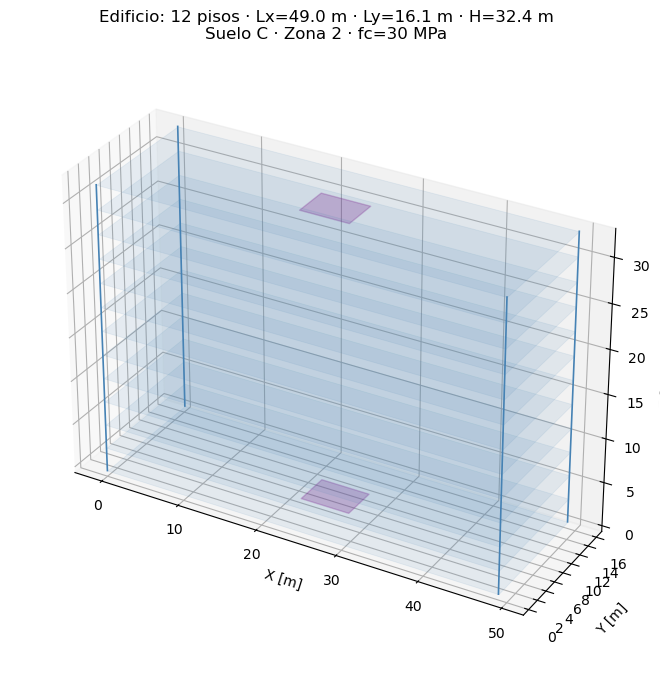


RESULTADOS — CUMPLE
  T1                : 0.6930 s
  Vb,x              : 6.22 kN
  Vb,y              : 5.79 kN
  Deriva x maxima   : 0.00009  (piso 11)
  Deriva y maxima   : 0.00076  (piso 11)
  Cumple deriva X   : si
  Cumple deriva Y   : si


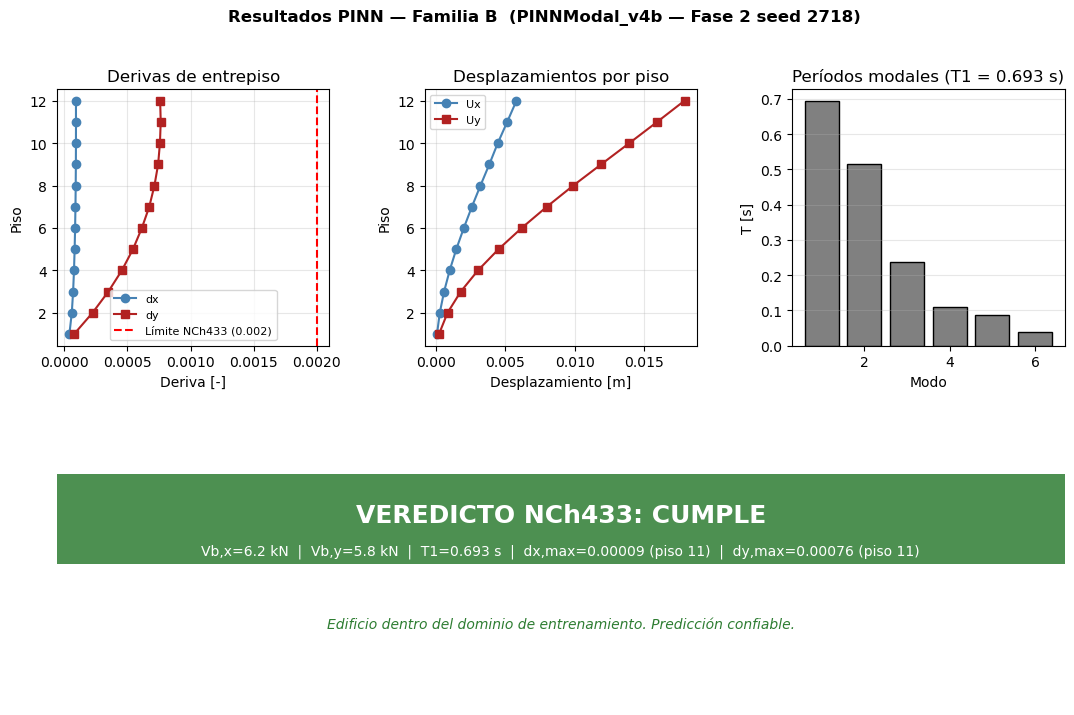

In [21]:
# ============================================================
# CELDA 10 — EJEMPLO DE USO (edita aquí tus parámetros)
# ============================================================

# (a) Definir el edificio — modo SIMPLE
edificio = edificio_simple(
    N_pisos=12,
    suelo='C',
    zona=2,
    n_unid_lado=3,
    fc_MPa=30,
)

# # (a') Alternativa — modo EXPERTO (descomenta y edita)
# edificio = edificio_experto(
#     N_pisos=12, n_unid_lado=3, activar_B2=1,
#     L_mod_m=3.5, prof_depto_m=7.5, ancho_corredor_m=1.7,
#     L_nucleo_m=6.0, B_nucleo_m=4.5, h_story_m=2.7,
#     fc_MPa=30, gk_kN_m2=7.0,
#     t_muro_nucleo_m=0.25, t_muro_borde_m=0.25, t_muro_mid_m=0.20,
#     suelo='C', zona=2,
# )

# (b) Visualizar el edificio ANTES de predecir
visualizar_edificio(edificio)

# (c) Predecir
res = predict_edificio(edificio)

# (d) Evaluar normativa
rep = reporte_normativo(res)

# (e) Imprimir resumen
print('\n' + '='*60)
print(f'RESULTADOS — {rep["veredicto"]}')
print('='*60)
print(f"  T1                : {rep['T1']:.4f} s")
print(f"  Vb,x              : {res['respuesta']['Vb_x']/1e3:,.2f} kN")
print(f"  Vb,y              : {res['respuesta']['Vb_y']/1e3:,.2f} kN")
print(f"  Deriva x maxima   : {rep['deriva_x_max']:.5f}  (piso {rep['piso_dx_max']})")
print(f"  Deriva y maxima   : {rep['deriva_y_max']:.5f}  (piso {rep['piso_dy_max']})")
print(f"  Cumple deriva X   : {'si' if rep['cumple_dx'] else 'NO'}")
print(f"  Cumple deriva Y   : {'si' if rep['cumple_dy'] else 'NO'}")
if rep['razones_fallo']:
    print('\n  Razones del incumplimiento:')
    for r in rep['razones_fallo']: print(f'    - {r}')
print('='*60)

# (f) Gráficos
graficar_resultados(res, rep)